# CellorNucEM API demo on the 6k quiz datasets

This notebook adapts the professor's original demo to the two local 6k quiz datasets. Its purpose is to make the ScanpyPlus API and outputs concrete before building the final quiz analysis.

It demonstrates:

1. loading the supplied signatures;
2. a global mixed cell/nucleus fit;
3. the columns and fit parameters written by `CellorNucEM`;
4. a constrained global fit on sc-only data;
5. optional saving without creating large files by default.

The saved outputs below are exploratory demonstrations, not the final quiz report.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

# Find the repository root whether Jupyter starts there or in scanpyplus/.
PROJECT_ROOT = next(
    (
        candidate
        for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (candidate / "data").is_dir() and (candidate / "scanpyplus").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the CellorNuc repository root.")

sys.path.insert(0, str(PROJECT_ROOT))
from scanpyplus import Scanpyplus

MIXED_PATH = PROJECT_ROOT / "data" / "mixed_mBDRC_5pCells_multiomeNuclei_6k.h5ad"
SINGLE_PATH = PROJECT_ROOT / "data" / "single_KidneyRaji_sc_6k.h5ad"

sc.settings.set_figure_params(dpi=100, facecolor="white", figsize=(5, 5))
pd.set_option("display.max_columns", 20)

print(f"Project root located: {PROJECT_ROOT.name}")
print(f"Mixed data:  {MIXED_PATH.name}")
print(f"Single data: {SINGLE_PATH.name}")

Project root located: CellorNuc
Mixed data:  mixed_mBDRC_5pCells_multiomeNuclei_6k.h5ad
Single data: single_KidneyRaji_sc_6k.h5ad


## 1. Load the gene signatures

`LoadGeneSignatures()` reads the default `hcka_v1` entry from `gene_signatures.json` and returns the sc-enriched and sn-enriched gene lists expected by `CellorNucEM`.

In [2]:
sc_genes, sn_genes = Scanpyplus.LoadGeneSignatures()

print(f"sc genes ({len(sc_genes)}): {sc_genes}")
print(f"sn genes ({len(sn_genes)}): {sn_genes}")

sc genes (10): ['EEF1A1', 'TPT1', 'FTH1', 'FTL', 'SERF2', 'ATP5F1E', 'GAPDH', 'UBA52', 'COX7C', 'MIF']
sn genes (10): ['FTX', 'AGAP1', 'GMDS-DT', 'PARD3', 'WWOX', 'MAGI2', 'PKHD1', 'NHS', 'AC098829.1', 'DPP6']


In [3]:
def signature_overlap(adata):
    """Report which supplied signature genes are measurable in an AnnData."""
    return pd.DataFrame(
        {
            "signature": ["sc", "sn"],
            "supplied": [len(sc_genes), len(sn_genes)],
            "found": [
                sum(gene in adata.var_names for gene in sc_genes),
                sum(gene in adata.var_names for gene in sn_genes),
            ],
            "missing": [
                [gene for gene in sc_genes if gene not in adata.var_names],
                [gene for gene in sn_genes if gene not in adata.var_names],
            ],
        }
    ).set_index("signature")


def summarize_global_fit(adata):
    """Convert raw beta-binomial parameters into interpretable quantities."""
    fit = adata.uns["modality_em"]["global"]
    a_cell, b_cell = fit["ab_cell"]
    a_nuc, b_nuc = fit["ab_nuc"]
    return pd.Series(
        {
            "cell_component_mean": a_cell / (a_cell + b_cell),
            "nucleus_component_mean": a_nuc / (a_nuc + b_nuc),
            "cell_concentration": a_cell + b_cell,
            "nucleus_concentration": a_nuc + b_nuc,
            "lam_cell": fit["lam_cell"],
            "component_separation": (
                a_cell / (a_cell + b_cell) - a_nuc / (a_nuc + b_nuc)
            ),
            "bic_1": fit["bic_1"],
            "bic_2": fit["bic_2"],
            "delta_bic_bic1_minus_bic2": fit["bic_1"] - fit["bic_2"],
            "loglik": fit["loglik"],
        },
        name="global_fit",
    )

## 2. Mixed cells + nuclei

The mixed 6k file has known modality in `obs['suspension_type']`, with values `cell` and `nucleus`. These are not the API defaults `sc` and `sn`, so the call must explicitly set `sc_label` and `sn_label`.

The mixture fit itself remains unsupervised: `assay_col` is used only to name final classes after fitting.

In [4]:
mixed = sc.read_h5ad(MIXED_PATH)

print(mixed)
print("\nKnown suspension types:")
print(mixed.obs["suspension_type"].value_counts())
print("\nAvailable layers:", list(mixed.layers.keys()))
print("Available embeddings:", list(mixed.obsm.keys()))
print("\nSignature overlap:")
display(signature_overlap(mixed))

AnnData object with n_obs × n_vars = 6000 × 29987
    obs: 'suspension_type', 'assay', 'donor_id', 'sex', 'cell_type', 'broad_cell_type', 'total_counts', 'n_genes', 'pct_counts_mt'
    var: 'ensembl_id'
    uns: 'source'
    obsm: 'X_umap'
    layers: 'counts'

Known suspension types:
suspension_type
cell       3000
nucleus    3000
Name: count, dtype: int64

Available layers: ['counts']
Available embeddings: ['X_umap']

Signature overlap:


,supplied,found,missing
signature,,,
sc,10,10,[]
sn,10,9,[AC098829.1]


### Known modality on the existing UMAP

This is a context plot only. `CellorNucEM` does not use UMAP coordinates when fitting the beta-binomial mixture.

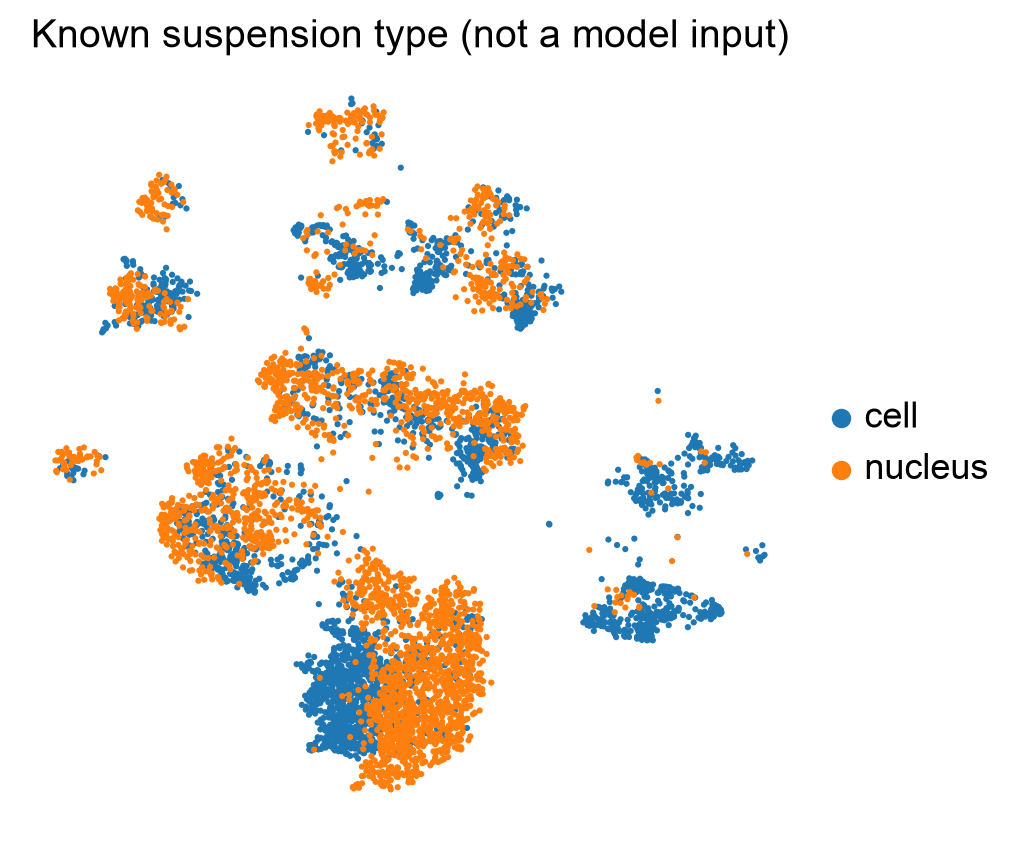

In [5]:
sc.pl.umap(
    mixed,
    color="suspension_type",
    title="Known suspension type (not a model input)",
    frameon=False,
)

### Run a global `CellorNucEM` fit

This call mirrors the professor's mixed-data demo:

- `layer='counts'` selects raw integer counts;
- `assay_col='suspension_type'` supplies label context only;
- `sc_label='cell'` and `sn_label='nucleus'` match this file's exact values;
- `gamma_hi=0.95` and `gamma_lo=0.05` require strong posterior evidence;
- `copy=True` returns a new modified object;
- omitted `cell_type_col` means one global fit;
- omitted `init` means `init='anchored'`;
- `print_mode=True` prints summaries and plots the existing UMAP.

modality_classification
Typical Cell (SC)         2735
Typical Nucleus (SN)      2048
Neutral                   1151
Nucleus-like Cell (SC)      59
Cell-like Nucleus (SN)       7
Name: count, dtype: int64 

modality_classification  Typical Cell (SC)  Nucleus-like Cell (SC)  \
suspension_type                                                      
cell                                  2735                      59   
nucleus                                  0                       0   

modality_classification  Typical Nucleus (SN)  Cell-like Nucleus (SN)  Neutral  
suspension_type                                                                 
cell                                        0                       0      206  
nucleus                                  2048                       7      945  


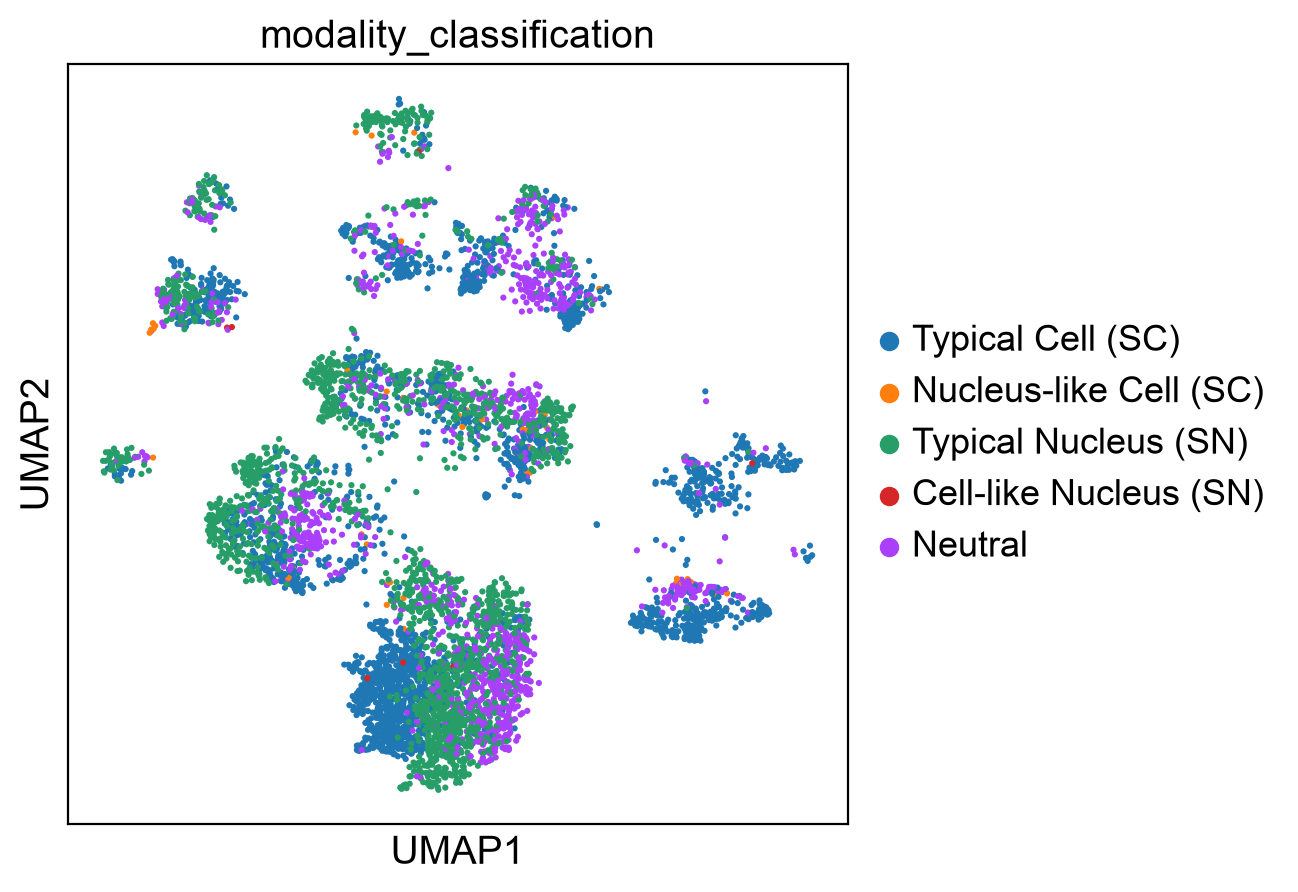

In [6]:
mixed = Scanpyplus.CellorNucEM(
    mixed,
    sc_genes,
    sn_genes,
    layer="counts",
    assay_col="suspension_type",
    sc_label="cell",
    sn_label="nucleus",
    gamma_hi=0.95,
    gamma_lo=0.05,
    copy=True,
    print_mode=True,
)

### Inspect what the API added

The per-droplet outputs live in `obs`. The fitted mixture parameters and diagnostics live in `uns['modality_em']`. The component means below are derived from the stored beta parameters as `a / (a + b)`.

In [7]:
added_columns = [
    "modality_counts",
    "sc_frac",
    "p_cell",
    "modality_fit",
    "modality_classification",
]

display(mixed.obs[added_columns].head())
print("\nGlobal fit summary:")
display(summarize_global_fit(mixed).to_frame())
print("\nClassification percentages:")
display(
    mixed.obs["modality_classification"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .to_frame()
)

,modality_counts,sc_frac,p_cell,modality_fit,modality_classification
AAAGATGCACACAGAG-1-0-scRNA5p,48,0.979167,1.0,global,Typical Cell (SC)
AAAGCAAGTTTCGCTC-1-0-scRNA5p,386,1.000000,1.0,global,Typical Cell (SC)
AAGGAGCTCAAGAAGT-1-0-scRNA5p,173,1.000000,1.0,global,Typical Cell (SC)
AAGGCAGAGAGAACAG-1-0-scRNA5p,226,1.000000,1.0,global,Typical Cell (SC)
AAGGTTCCACAGGAGT-1-0-scRNA5p,388,0.992268,1.0,global,Typical Cell (SC)



Global fit summary:


,global_fit
cell_component_mean,0.961452
nucleus_component_mean,0.113037
cell_concentration,7.072116
nucleus_concentration,7.407356
lam_cell,0.562463
component_separation,0.848415
bic_1,33667.097613
bic_2,32247.674700
delta_bic_bic1_minus_bic2,1419.422913
loglik,-16102.537875



Classification percentages:


,percent
modality_classification,
Typical Cell (SC),45.583333
Typical Nucleus (SN),34.133333
Neutral,19.183333
Nucleus-like Cell (SC),0.983333
Cell-like Nucleus (SN),0.116667


### Inspect evidence, raw fraction, and posterior

These plots distinguish three API outputs:

- `modality_counts = x + y`: amount of signature evidence;
- `sc_frac = x / (x + y)`: observed signature fraction;
- `p_cell`: fitted posterior probability of the high-mean component.

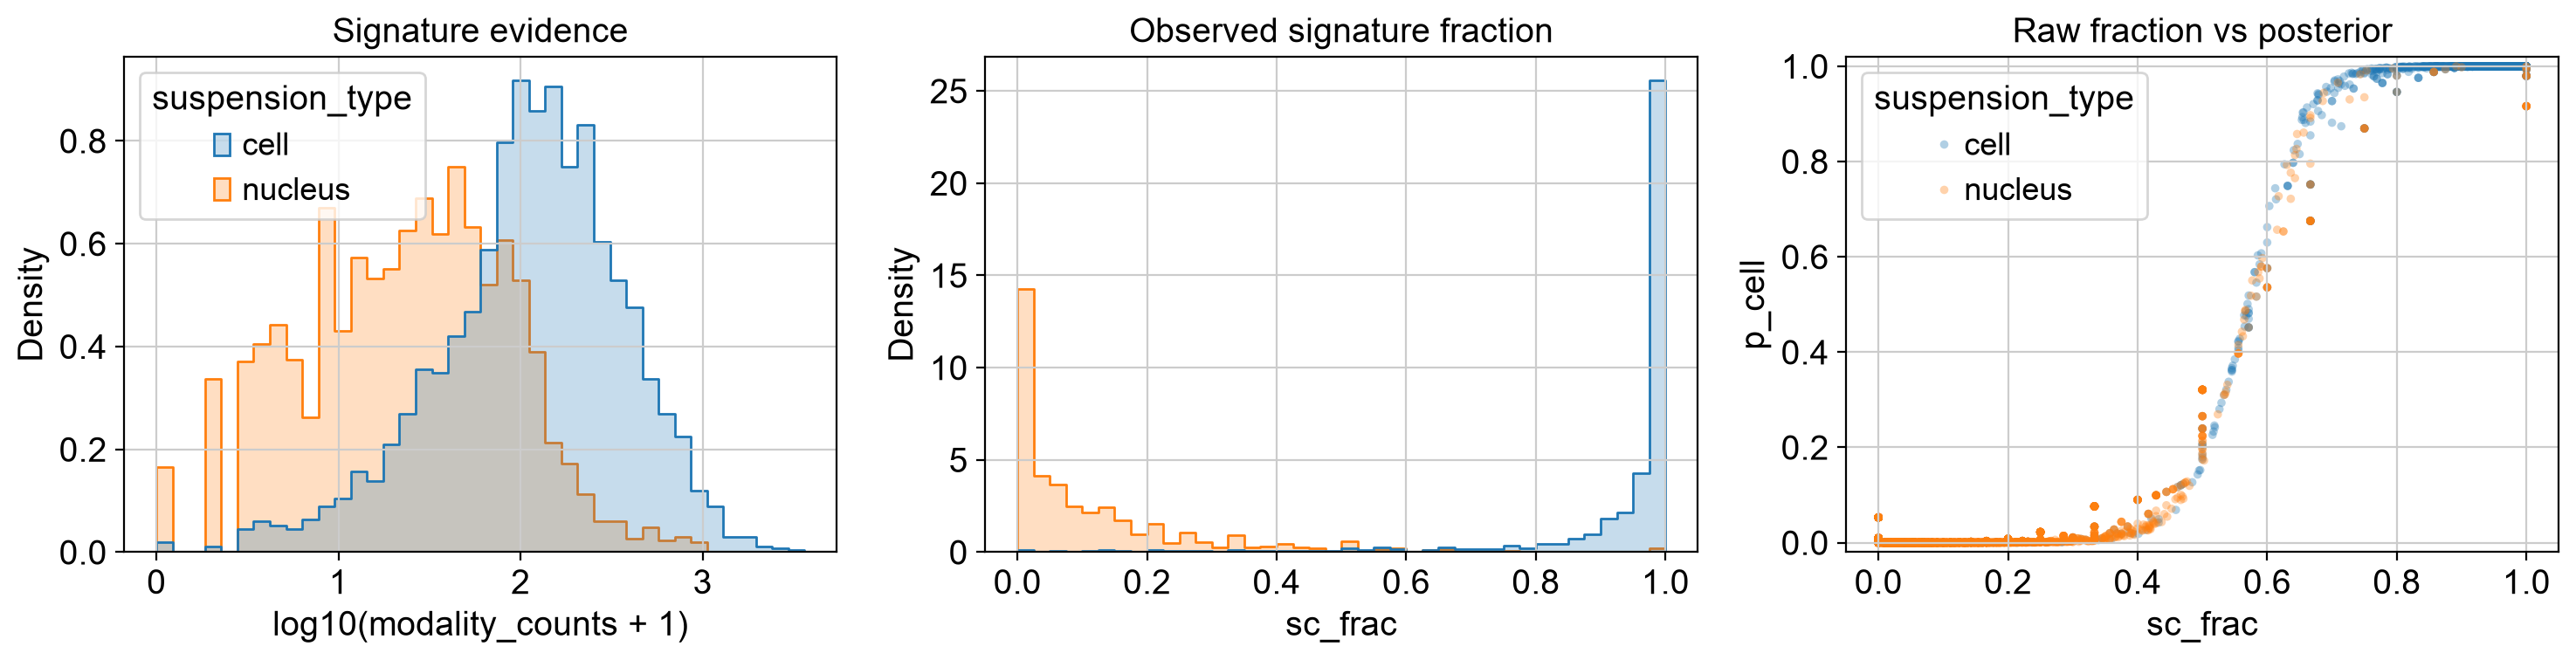

In [8]:
mixed_plot = mixed.obs[
    ["suspension_type", "modality_counts", "sc_frac", "p_cell"]
].copy()
mixed_plot["log10_signature_counts_plus_1"] = np.log10(
    mixed_plot["modality_counts"] + 1
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(
    data=mixed_plot,
    x="log10_signature_counts_plus_1",
    hue="suspension_type",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Signature evidence")
axes[0].set_xlabel("log10(modality_counts + 1)")

sns.histplot(
    data=mixed_plot,
    x="sc_frac",
    hue="suspension_type",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Observed signature fraction")

sns.scatterplot(
    data=mixed_plot,
    x="sc_frac",
    y="p_cell",
    hue="suspension_type",
    s=12,
    alpha=0.35,
    linewidth=0,
    ax=axes[2],
)
axes[2].set_title("Raw fraction vs posterior")
axes[2].set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

### Optional save

Saving is disabled by default so an exploratory notebook run does not silently create another large `.h5ad` file.

In [9]:
SAVE_RESULTS = False

if SAVE_RESULTS:
    output_path = PROJECT_ROOT / "results" / "q1" / "mixed_6k_cellornuc_demo.h5ad"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    mixed.write_h5ad(output_path)
    print(f"Saved {output_path}")
else:
    print("SAVE_RESULTS is False; mixed result remains in memory only.")

SAVE_RESULTS is False; mixed result remains in memory only.


## 3. Single-modality sc data

The single 6k file does not contain an sc/sn assay column. As in the professor's demo, we add a constant `modality='sc'` column to provide known assay context for final label names.

The fit remains based on signature counts, not on this metadata column.

In [10]:
single = ad.read_h5ad(SINGLE_PATH)
single.obs["modality"] = "sc"

print(single)
print("\nKnown modality values:", single.obs["modality"].unique().tolist())
print("Available layers:", list(single.layers.keys()))
print("Available embeddings:", list(single.obsm.keys()))
print("\nSignature overlap:")
display(signature_overlap(single))

AnnData object with n_obs × n_vars = 6000 × 28562
    obs: 'batch', 'leiden', 'Predicted', 'reannotated_celltype', 'n_counts', 'n_genes', 'percent_mito', 'phase', 'modality'
    var: 'gene_ids'
    uns: 'source'
    obsm: 'X_umap'
    layers: 'counts'

Known modality values: ['sc']
Available layers: ['counts']
Available embeddings: ['X_umap']

Signature overlap:


,supplied,found,missing
signature,,,
sc,10,10,[]
sn,10,10,[]


### Run the constrained sc-only fit

This mirrors the professor's single-modality call. It still uses anchored initialization, but adds component-mean constraints:

- `max_p_nuc=0.2`: keep the low component mean at or below 0.2;
- `min_p_cell=0.8`: keep the high component mean at or above 0.8.

In recognized sc-only data, undecided observations are folded into `Typical Cell (SC)`. A `Nucleus-like Cell (SC)` call requires sufficient signature counts and `p_cell < gamma_lo`.

Single-modality data (sc only): 1220 undecided droplets assigned to 'Typical Cell (SC)'.

modality_classification
Typical Cell (SC)         5820
Nucleus-like Cell (SC)     180
Name: count, dtype: int64 

modality_classification  Typical Cell (SC)  Nucleus-like Cell (SC)
modality                                                          
sc                                    5820                     180


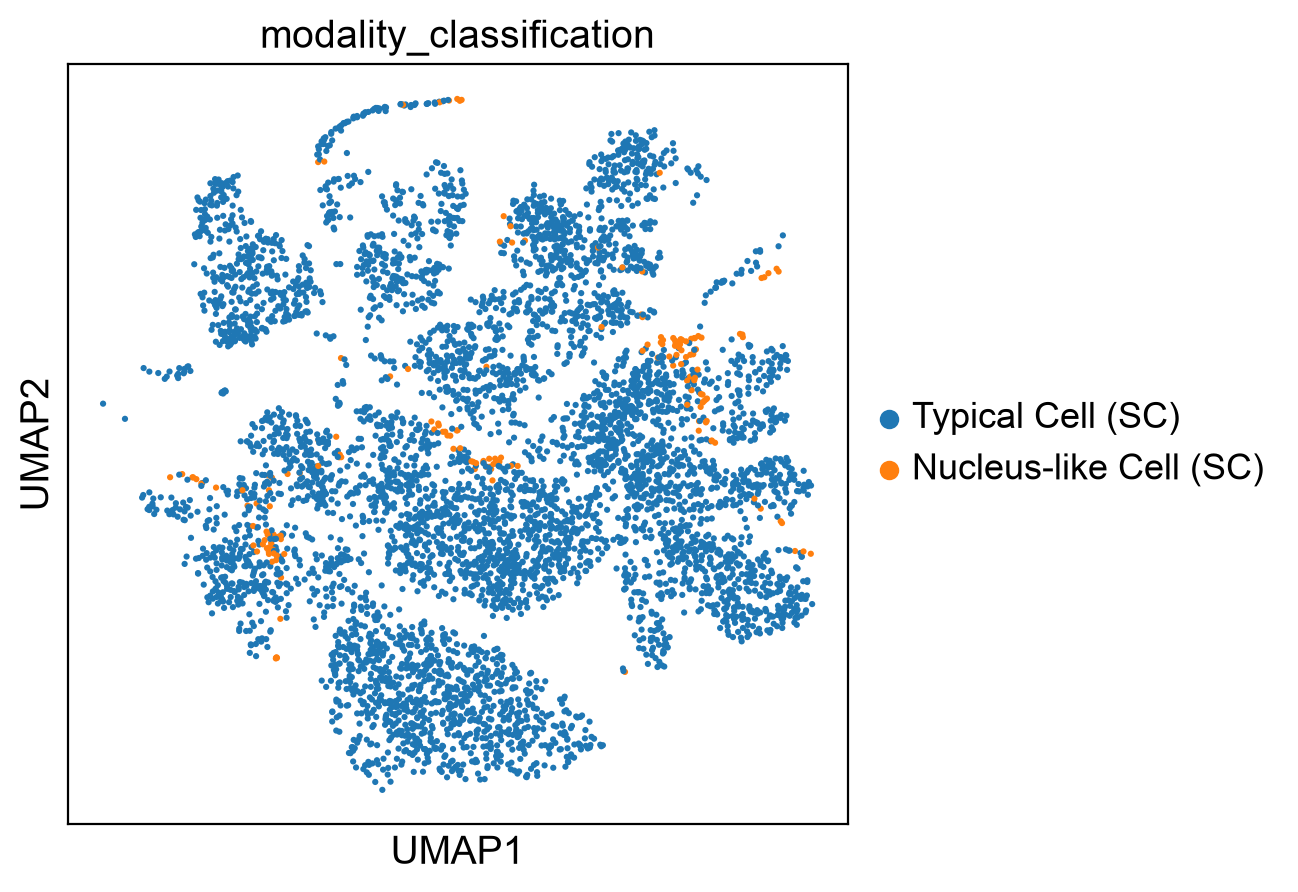

In [11]:
single = Scanpyplus.CellorNucEM(
    single,
    sc_genes,
    sn_genes,
    assay_col="modality",
    layer="counts",
    copy=True,
    gamma_hi=0.95,
    gamma_lo=0.05,
    max_p_nuc=0.2,
    min_p_cell=0.8,
    print_mode=True,
)

### Inspect the sc-only outputs

Notice that the component means describe the two fitted populations, while each row's `p_cell` is its posterior membership probability.

In [12]:
display(single.obs[added_columns].head())
print("\nGlobal fit summary:")
display(summarize_global_fit(single).to_frame())
print("\nClassification percentages:")
display(
    single.obs["modality_classification"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percent")
    .to_frame()
)

,modality_counts,sc_frac,p_cell,modality_fit,modality_classification
AAAGAACGTGCGTGCT-1150-EO-1,125,0.960000,0.998271,global,Typical Cell (SC)
AAAGAACTCGTTGTTT-1150-EO-1,146,0.938356,0.997148,global,Typical Cell (SC)
AAAGGATTCAAGCTTG-1150-EO-1,56,0.696429,0.960083,global,Typical Cell (SC)
AAAGGGCCAGGATCTT-1150-EO-1,312,0.987179,0.999523,global,Typical Cell (SC)
AAAGGGCTCTTCTCAA-1150-EO-1,176,0.988636,0.999541,global,Typical Cell (SC)



Global fit summary:


,global_fit
cell_component_mean,0.909144
nucleus_component_mean,0.200000
cell_concentration,4.218520
nucleus_concentration,1.809886
lam_cell,0.935251
component_separation,0.709144
bic_1,31605.320513
bic_2,30942.811705
delta_bic_bic1_minus_bic2,662.508808
loglik,-15449.972864



Classification percentages:


,percent
modality_classification,
Typical Cell (SC),97.0
Nucleus-like Cell (SC),3.0


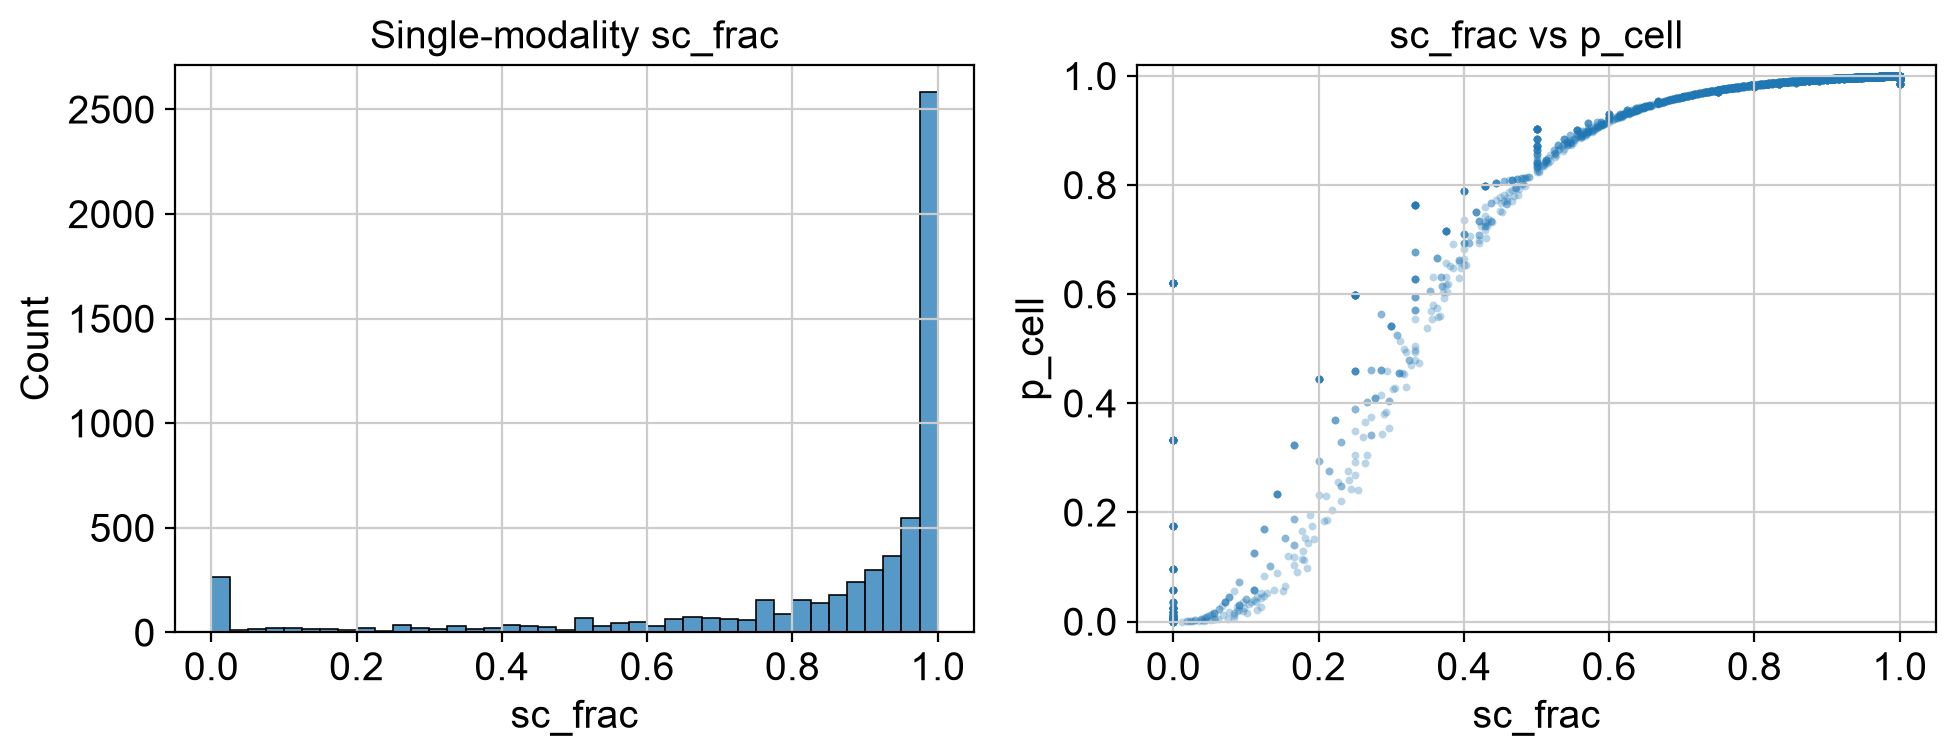

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(single.obs["sc_frac"].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Single-modality sc_frac")
axes[0].set_xlabel("sc_frac")

axes[1].scatter(
    single.obs["sc_frac"],
    single.obs["p_cell"],
    s=8,
    alpha=0.3,
    linewidths=0,
)
axes[1].set_title("sc_frac vs p_cell")
axes[1].set_xlabel("sc_frac")
axes[1].set_ylabel("p_cell")
axes[1].set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

In [14]:
SAVE_RESULTS = False

if SAVE_RESULTS:
    output_path = PROJECT_ROOT / "results" / "q2" / "single_6k_cellornuc_demo.h5ad"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    single.write_h5ad(output_path)
    print(f"Saved {output_path}")
else:
    print("SAVE_RESULTS is False; single-modality result remains in memory only.")

SAVE_RESULTS is False; single-modality result remains in memory only.


## 4. API takeaways

- `LoadGeneSignatures()` supplies the two gene lists.
- `CellorNucEM` needs raw signature counts from `adata.X` or a named layer.
- `assay_col` changes label interpretation but does not fit the mixture.
- `cell_type_col=None` gives a global fit.
- `init='anchored'` is the default initialization.
- Component-mean constraints are separate from initialization anchors.
- Per-droplet results are stored in `adata.obs`.
- Fit parameters and BIC diagnostics are stored in `adata.uns['modality_em']`.
- `copy=True` requires assigning the returned object.
- `print_mode=True` prints summaries and plots UMAP when `X_umap` exists.